# Robustness Sweeps for Lag-Context Learning Rules

Companion to `hetero_rules_run.ipynb` -- this notebook assumes that notebook's setup is
already familiar: the update rule, `CONFIG`, the rule catalogue (`self`, `forward`,
`skip-two`, `self+forward`, `forward+skip2`, `bigram`, `multilag`, `coh bigram`,
`coh trigram`), and the corrected single-sequence scoring methodology (retrieval rate
first, mean overlap only over correctly-retrieved trials). No context is re-derived here.

Three sweeps, each testing a different axis of robustness for a single, non-branching
stored sequence:

1. **Hamming distance** between consecutive stored patterns (moved from
   `hetero_rules_run.ipynb`'s old Part IV).
2. **Network size `N`**, at a fixed `corruption_rate` (so absolute Hamming distance grows
   with `N`).
3. **Superposition of learning rules** -- mixing pairs of the four context rules
   (`bigram`, `coh bigram`, `coh trigram`, `multilag`) at varying relative weight.

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import itertools

import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path


root_dir = Path.cwd().parent.parent
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import kuramoto.kuramoto_library as krm
import kuramoto.hetero_learning.kuramoto_hetero as kc

In [2]:
CONFIG = dict(
    dt=0.05,
    T=30.0,
    frequency_std=0.3,
    phase_noise=0.01,
    d=3,
    corruption_rate=0.2,
    tolerance=0.5,
    mode="ode",
)

N = 100
MARGIN = 0.01
SEED_POOL = 10_000
SINGLE_SEQ_TRIALS = 100

assert CONFIG["frequency_std"] > 0

In [3]:
RAW_CATALOGUE = {
    "self":          kc.self_rule(),
    "forward":       kc.forward_rule(),
    "skip-two":      kc.skip_rule(nhop=2),
    "self+forward":  kc.mixture(kc.self_rule(weight=0.3), kc.forward_rule(weight=1.0)),
    "forward+skip2": kc.mixture(kc.forward_rule(weight=1.0), kc.skip_rule(2, weight=0.5)),
    "bigram":        kc.bigram_rule(),
    "multilag":      kc.multilag_rule((1.0, 1.0, 1.0)),
    "coh bigram":    kc.coherent_bigram_rule(),
    "coh trigram":   kc.coherent_trigram_rule(),
}

## Scoring: retrieval rate first, then mean overlap

Same methodology as `hetero_rules_run.ipynb`'s Part IV: a trial only contributes to
`mean_overlap` if it was fully and correctly retrieved
(`compare_to_stored_sequence(retrieved, seq) == len(seq)`); a failed trial only lowers
`retrieval_rate`. `N` is an explicit parameter here (rather than a fixed global) so the
same function drives both the Hamming and the `N` sweep.

In [4]:
def mean_overlap_score(result, seq):
    """Mean, over every non-cue pattern in `seq`, of its own peak overlap, from an
    already-computed simulate() result. Only meaningful for a correctly retrieved trial --
    callers must check that separately (see single_sequence_score_sweep)."""
    return float(result["overlaps"][:, 1:].max(axis=0).mean())


def generate_random_sequence(N, seq_len, name, seed):
    """A sequence of seq_len+1 INDEPENDENTLY random patterns -- no mutation chain, unlike
    generate_sequence, so consecutive patterns are unrelated rather than similar."""
    rng = np.random.default_rng(seed)
    patterns = [rng.choice([0.0, np.pi], size=N) for _ in range(seq_len + 1)]
    return krm.sequence_from_patterns(name, patterns)


def single_sequence_score_sweep(catalogue, seq_len, corruption_rate, N, trials=SINGLE_SEQ_TRIALS, seed=0,
                                 boundary=None, config_overrides=None, cue_corruption_rate=0.0,
                                 random_patterns=False):
    """For each rule, run `trials` freshly generated single sequences of size `N` and report:
      - retrieval_rate: fraction of trials with perfect sequential recall.
      - mean_overlap: mean_overlap_score averaged ONLY over the correctly retrieved trials
        (nan if none were).

    boundary: passed straight through to net.simulate (None/"self" settles at the last
        pattern, "cycle" loops back to the first) -- used by the loop-vs-no-loop test.
    config_overrides: dict merged over CONFIG for this call (e.g. frequency_mean/std) --
        used by the frequency-condition tests.
    cue_corruption_rate: if > 0, cue from a corrupted copy of seq[0] instead of the exact
        stored pattern. Needed for omega=0 configurations: an exact, uncorrupted cue has
        theta in {0, pi} everywhere, so sin(theta)=0 and, with no frequency disorder either,
        the drive vanishes identically and the trajectory never leaves the cue.
    random_patterns: if True, use generate_random_sequence instead of generate_sequence --
        stored patterns are independent rather than a mutation chain (corruption_rate is
        then unused).
    """
    rng = np.random.default_rng(seed)
    net_config = {**CONFIG, **(config_overrides or {})}
    results = {}
    for name, rule in catalogue.items():
        net = kc.ContextNetwork(rule=rule, N=N, seed=10, **net_config)
        overlap_vals, n_correct = [], 0
        for _ in range(trials):
            if random_patterns:
                seq = generate_random_sequence(N, seq_len, name="A", seed=int(rng.integers(SEED_POOL)))
            else:
                seq = krm.generate_sequence(N, seq_len, corruption_rate, name="A",
                                            seed=int(rng.integers(SEED_POOL)))
            if cue_corruption_rate > 0:
                theta_init = seq.cue(0, corruption_rate=cue_corruption_rate, seed=int(rng.integers(SEED_POOL)))
                theta_history, time = net._integrate(seq, theta_init, None, None, None, boundary)
                result = {"time": time, "theta_history": theta_history, "overlaps": net.overlaps(theta_history, seq)}
            else:
                result = net.simulate(seq, boundary=boundary)
            retrieved = net.decode_sequence_online(result, seq, margin=MARGIN)
            if net.compare_to_stored_sequence(retrieved, seq) == len(seq):
                n_correct += 1
                overlap_vals.append(mean_overlap_score(result, seq))
        results[name] = dict(
            retrieval_rate=n_correct / trials,
            mean_overlap=float(np.mean(overlap_vals)) if overlap_vals else float("nan"),
        )
    return results

## 1. Hamming-distance breakdown sweep

`corruption_rate` is exactly `flips / N`, so sweeping it sweeps the Hamming distance
between consecutive stored patterns directly: `hamming = int(corruption_rate * N)`.

The curve is not guaranteed to be monotonic, and in practice isn't for every rule: at very
low Hamming distance, consecutive patterns are so similar that the margin-based decoder
(`decode_sequence_online`) can fail to tell them apart at all (the winner-take-all switch
needs a challenger to beat the current pattern's overlap by `margin`, which is hard when
two patterns' overlaps are both large and nearly equal) -- a *different* failure mode from
the high-distance one (weak drive under too much accumulated drift). So "breakdown point"
below is reported as the **largest** Hamming distance at which `retrieval_rate >= 50%`
(scanning from the high-distance end), not the first point that dips below 50% -- the first
crossing can land on the low-distance, near-duplicate-confusion failure instead of the
drift-tolerance ceiling actually of interest. A rule that also fails at the smallest
distance tested is flagged separately.

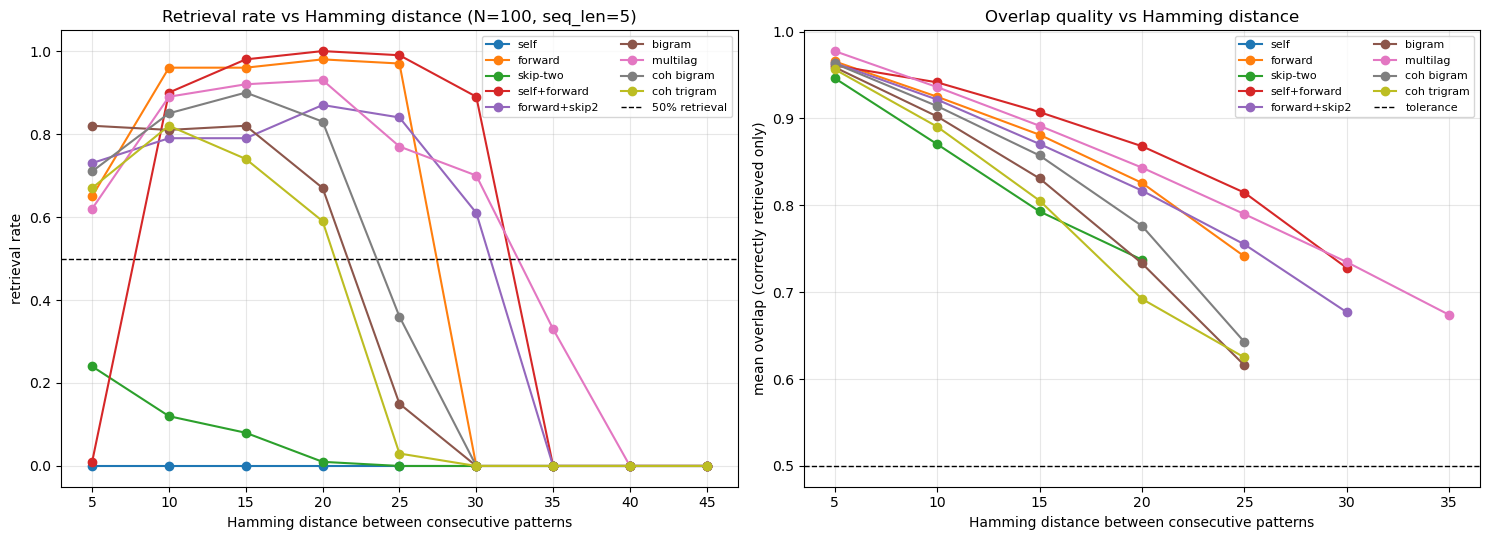

rule             largest Hamming distance with retrieval >= 50%    fails at smallest distance too?
----------------------------------------------------------------------------------------------------
self                                  never (over tested range)                                yes
forward                                                      25                                 no
skip-two                              never (over tested range)                                yes
self+forward                                                 30                                yes
forward+skip2                                                30                                 no
bigram                                                       20                                 no
multilag                                                     30                                 no
coh bigram                                                   20                                 no
coh trig

In [5]:
HAMMING_SWEEP_RATES = np.linspace(0.05, 0.45, 9)

def hamming_breakdown_sweep(catalogue, seq_len, rates, N, trials=SINGLE_SEQ_TRIALS, seed=0):
    return {rate: single_sequence_score_sweep(catalogue, seq_len, rate, N, trials=trials, seed=seed)
            for rate in rates}

hamming_results = hamming_breakdown_sweep(RAW_CATALOGUE, seq_len=5, rates=HAMMING_SWEEP_RATES, N=N)
hamming_dist = (HAMMING_SWEEP_RATES * N).astype(int)

retrieval_by_rule = {name: [hamming_results[rate][name]["retrieval_rate"] for rate in HAMMING_SWEEP_RATES]
                     for name in RAW_CATALOGUE}
overlap_by_rule = {name: [hamming_results[rate][name]["mean_overlap"] for rate in HAMMING_SWEEP_RATES]
                   for name in RAW_CATALOGUE}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for name in RAW_CATALOGUE:
    axes[0].plot(hamming_dist, retrieval_by_rule[name], "-o", label=name)
    axes[1].plot(hamming_dist, overlap_by_rule[name], "-o", label=name)
axes[0].axhline(0.5, color="k", ls="--", lw=1, label="50% retrieval")
axes[0].set_xlabel("Hamming distance between consecutive patterns")
axes[0].set_ylabel("retrieval rate")
axes[0].set_title(f"Retrieval rate vs Hamming distance (N={N}, seq_len=5)")
axes[0].legend(fontsize=8, ncol=2); axes[0].grid(alpha=0.3)

axes[1].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1, label="tolerance")
axes[1].set_xlabel("Hamming distance between consecutive patterns")
axes[1].set_ylabel("mean overlap (correctly retrieved only)")
axes[1].set_title("Overlap quality vs Hamming distance")
axes[1].legend(fontsize=8, ncol=2); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'rule':<15}{'largest Hamming distance with retrieval >= 50%':>48}   {'fails at smallest distance too?':>32}")
print("-" * 100)
for name in RAW_CATALOGUE:
    passing = [d for d, r in zip(hamming_dist, retrieval_by_rule[name]) if r >= 0.5]
    tag = str(max(passing)) if passing else "never (over tested range)"
    low_end_fails = retrieval_by_rule[name][0] < 0.5
    print(f"{name:<15}{tag:>48}   {'yes' if low_end_fails else 'no':>32}")

## 2. Network-size sweep

`corruption_rate` is held fixed at `CONFIG["corruption_rate"]` across every `N` tested, so
absolute Hamming distance between consecutive patterns grows with `N`
(`= corruption_rate * N`) -- this asks whether a bigger network makes the same *relative*
task (same fraction of neurons flipped per step) easier or harder, not whether it can
tolerate the same absolute perturbation.

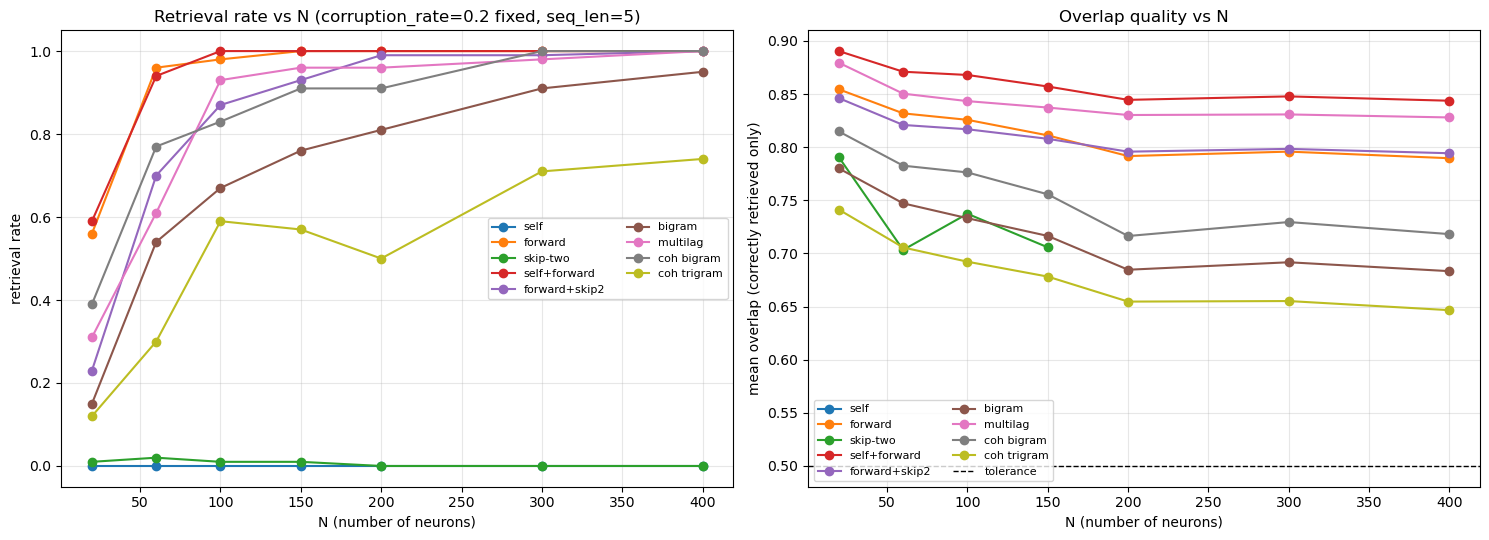

rule           N=20     N=60     N=100    N=150    N=200    N=300    N=400    
self           0%      0%      0%      0%      0%      0%      0%      
forward        56%     96%     98%     100%    100%    100%    100%    
skip-two       1%      2%      1%      1%      0%      0%      0%      
self+forward   59%     94%     100%    100%    100%    100%    100%    
forward+skip2  23%     70%     87%     93%     99%     99%     100%    
bigram         15%     54%     67%     76%     81%     91%     95%     
multilag       31%     61%     93%     96%     96%     98%     100%    
coh bigram     39%     77%     83%     91%     91%     100%    100%    
coh trigram    12%     30%     59%     57%     50%     71%     74%     


In [6]:
N_SWEEP = [20, 60, 100, 150, 200, 300, 400]

n_sweep_results = {
    n: single_sequence_score_sweep(RAW_CATALOGUE, seq_len=5,
                                   corruption_rate=CONFIG["corruption_rate"],
                                   N=n, trials=SINGLE_SEQ_TRIALS)
    for n in N_SWEEP
}

retrieval_by_rule_n = {name: [n_sweep_results[n][name]["retrieval_rate"] for n in N_SWEEP]
                       for name in RAW_CATALOGUE}
overlap_by_rule_n = {name: [n_sweep_results[n][name]["mean_overlap"] for n in N_SWEEP]
                     for name in RAW_CATALOGUE}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for name in RAW_CATALOGUE:
    axes[0].plot(N_SWEEP, retrieval_by_rule_n[name], "-o", label=name)
    axes[1].plot(N_SWEEP, overlap_by_rule_n[name], "-o", label=name)
axes[0].set_xlabel("N (number of neurons)"); axes[0].set_ylabel("retrieval rate")
axes[0].set_title(f"Retrieval rate vs N (corruption_rate={CONFIG['corruption_rate']} fixed, seq_len=5)")
axes[0].legend(fontsize=8, ncol=2); axes[0].grid(alpha=0.3)

axes[1].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1, label="tolerance")
axes[1].set_xlabel("N (number of neurons)"); axes[1].set_ylabel("mean overlap (correctly retrieved only)")
axes[1].set_title("Overlap quality vs N")
axes[1].legend(fontsize=8, ncol=2); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'rule':<15}" + "".join(f"N={n:<7}" for n in N_SWEEP))
for name in RAW_CATALOGUE:
    print(f"{name:<15}" + "".join(f"{retrieval_by_rule_n[name][i]:<8.0%}" for i in range(len(N_SWEEP))))

## 3. Superposition of learning rules

All `C(4,2) = 6` pairs among the four context rules (`bigram`, `coh bigram`, `coh trigram`,
`multilag`), mixed via `kc.mixture` at relative weight `w` (`w=0` is the pure first rule,
`w=1` the pure second). `multilag_rule` doesn't take a single `weight=` kwarg the way the
other three builders do -- its weight lives across three rows (one per lag), not one --
so the mixing coefficient is applied uniformly to a rule's *whole* weight column after
construction (`scaled`, below), rather than relying on each builder's own `weight=`
argument. This treats all four base rules the same way regardless of how many rows they
expand to.

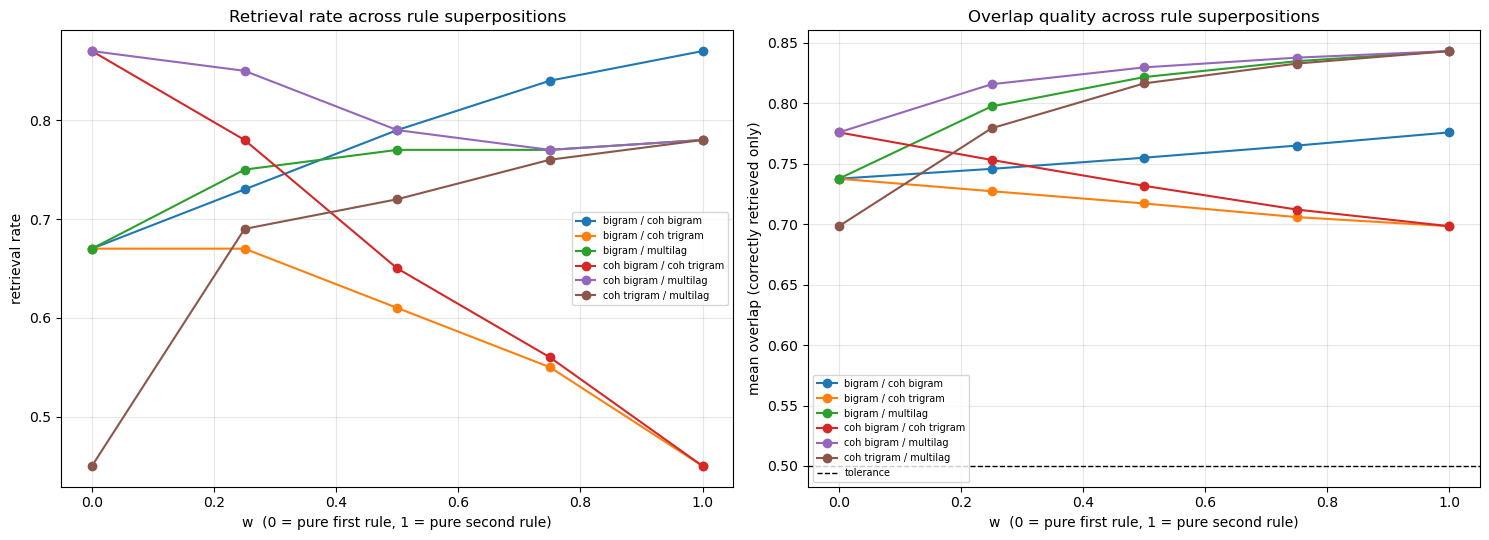

pair                        w=0        w=0.25     w=0.5      w=0.75     w=1        
bigram / coh bigram         67%       73%       79%       84%       87%       
bigram / coh trigram        67%       67%       61%       55%       45%       
bigram / multilag           67%       75%       77%       77%       78%       
coh bigram / coh trigram    87%       78%       65%       56%       45%       
coh bigram / multilag       87%       85%       79%       77%       78%       
coh trigram / multilag      45%       69%       72%       76%       78%       


In [7]:
BASE_RULES = {
    "bigram":      kc.bigram_rule(),
    "coh bigram":  kc.coherent_bigram_rule(),
    "coh trigram": kc.coherent_trigram_rule(),
    "multilag":    kc.multilag_rule((1.0, 1.0, 1.0)),
}


def scaled(rule, w):
    """Copy of `rule` with its whole weight column multiplied by w -- works uniformly for
    single-row and multi-row rules, unlike passing weight= to the original builder."""
    rule = np.atleast_2d(np.asarray(rule, dtype=np.float64)).copy()
    rule[:, -1] *= w
    return rule


SUPERPOSITION_WEIGHTS = [0.0, 0.25, 0.5, 0.75, 1.0]

superposition_results = {}
for name_a, name_b in itertools.combinations(BASE_RULES, 2):
    pair_label = f"{name_a} / {name_b}"
    per_weight = []
    for w in SUPERPOSITION_WEIGHTS:
        rule = kc.mixture(scaled(BASE_RULES[name_a], 1 - w), scaled(BASE_RULES[name_b], w))
        result = single_sequence_score_sweep({pair_label: rule}, seq_len=5,
                                             corruption_rate=CONFIG["corruption_rate"],
                                             N=N, trials=SINGLE_SEQ_TRIALS)
        per_weight.append(result[pair_label])
    superposition_results[pair_label] = per_weight

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for pair_label, per_weight in superposition_results.items():
    axes[0].plot(SUPERPOSITION_WEIGHTS, [r["retrieval_rate"] for r in per_weight], "-o", label=pair_label)
    axes[1].plot(SUPERPOSITION_WEIGHTS, [r["mean_overlap"] for r in per_weight], "-o", label=pair_label)
axes[0].set_xlabel("w  (0 = pure first rule, 1 = pure second rule)")
axes[0].set_ylabel("retrieval rate")
axes[0].set_title("Retrieval rate across rule superpositions")
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

axes[1].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1, label="tolerance")
axes[1].set_xlabel("w  (0 = pure first rule, 1 = pure second rule)")
axes[1].set_ylabel("mean overlap (correctly retrieved only)")
axes[1].set_title("Overlap quality across rule superpositions")
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'pair':<28}" + "".join(f"w={w:<9g}" for w in SUPERPOSITION_WEIGHTS))
for pair_label, per_weight in superposition_results.items():
    print(f"{pair_label:<28}" + "".join(f"{r['retrieval_rate']:<10.0%}" for r in per_weight))


---

## 4. Mean overlap for crossover geometries

Every sweep above scored a single, non-branching sequence. The same correctness-first mean
overlap methodology extends to the two-sequence crossover experiments from
`hetero_rules_run.ipynb`: a cueing attempt only contributes to `mean_overlap` when
`classify_unshared` calls it `"correct"` (every *unshared* pattern of the cued branch
decoded, in order); a failed attempt only lowers `retrieval_rate`. Shared positions are
excluded from the overlap average since both branches store the identical pattern there --
it carries no rule-discriminating information.

Three before-shared-after geometries are tested: `1-1-1`, `2-1-2`, and `1-3-1` -- the same
three used in `hetero_rules_run.ipynb`, for comparability.

-- 1-1-1 --
  self            retrieval_rate=   0%   mean_overlap=n/a
  forward         retrieval_rate=  50%   mean_overlap=+0.982
  skip-two        retrieval_rate= 100%   mean_overlap=+0.987
  self+forward    retrieval_rate=   2%   mean_overlap=+0.972
  forward+skip2   retrieval_rate=  80%   mean_overlap=+0.995
  bigram          retrieval_rate=  56%   mean_overlap=+0.892
  multilag        retrieval_rate=   9%   mean_overlap=+0.989
  coh bigram      retrieval_rate=  63%   mean_overlap=+0.945
  coh trigram     retrieval_rate=  62%   mean_overlap=+0.884
-- 2-1-2 --
  self            retrieval_rate=   0%   mean_overlap=n/a
  forward         retrieval_rate=  44%   mean_overlap=+0.882
  skip-two        retrieval_rate=   4%   mean_overlap=+0.825
  self+forward    retrieval_rate=  17%   mean_overlap=+0.907
  forward+skip2   retrieval_rate=  50%   mean_overlap=+0.879
  bigram          retrieval_rate=  60%   mean_overlap=+0.807
  multilag        retrieval_rate=  55%   mean_overlap=+0.903
  coh 

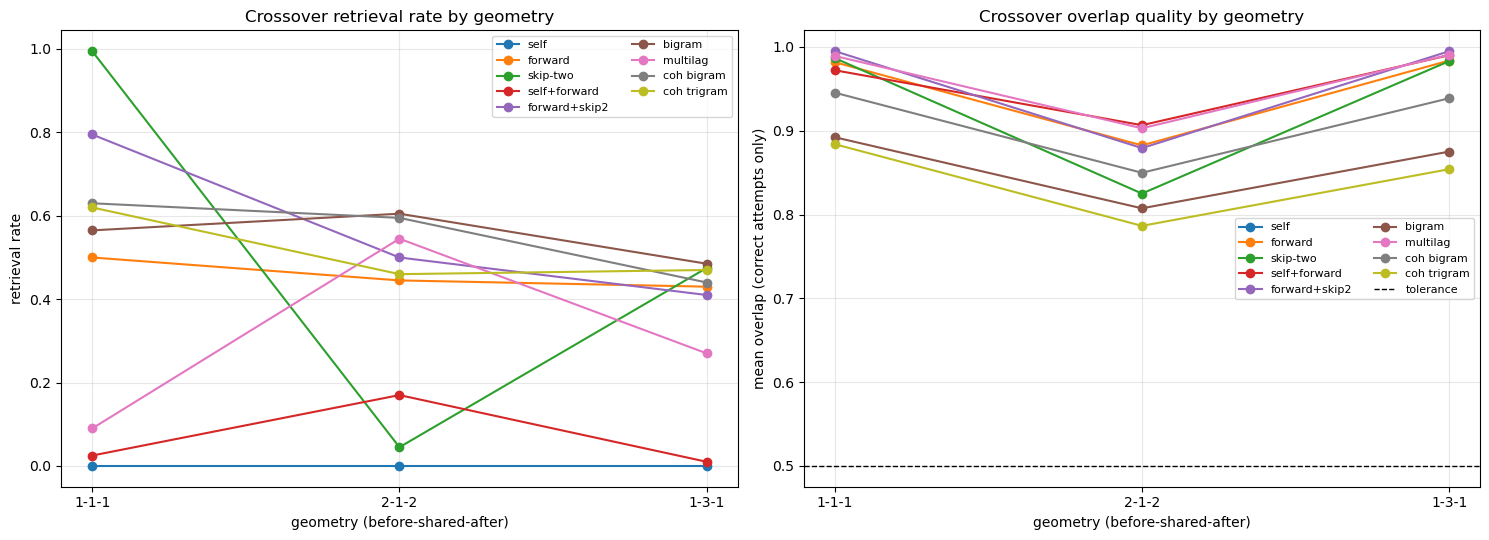

In [8]:
def make_crossover_multisequence3(N, corruption_rate, origin_seed, mutation_seeds,
                                  seq_len, shared_idx):
    """Two sequences of `seq_len` patterns sharing a contiguous run at `shared_idx`.
    Ported from hetero_rules_run.ipynb -- see that notebook for the full explanation."""
    shared_idx = sorted(shared_idx)
    lo, hi = shared_idx[0], shared_idx[-1]
    if shared_idx != list(range(lo, hi + 1)):
        raise ValueError("shared_idx must be a contiguous run.")
    if not (0 < lo and hi < seq_len - 1):
        raise ValueError("The run needs at least one unshared pattern on each side.")

    seeds = iter(mutation_seeds)
    mutate = lambda v: krm.corrupt_phase(v, corruption_rate, np.random.default_rng(next(seeds)))

    run = [np.random.default_rng(origin_seed).choice([0.0, np.pi], size=N)]
    for _ in range(hi - lo):
        run.append(mutate(run[-1]))

    multi = krm.MultiSequence()
    for name in ("A", "B"):
        prefix, v = [], run[0]
        for _ in range(lo):
            v = mutate(v); prefix.append(v)
        prefix.reverse()
        suffix, v = [], run[-1]
        for _ in range(seq_len - 1 - hi):
            v = mutate(v); suffix.append(v)
        multi.add(krm.sequence_from_patterns(name, prefix + list(run) + suffix))
    return multi


def classify_unshared(retrieved, multi, name, shared_idx):
    """correct = all unshared positions of the cued branch decoded, in order.
    Ported from hetero_rules_run.ipynb -- see that notebook for the full explanation."""
    other = "B" if name == "A" else "A"
    shared = set(shared_idx)
    pending = iter([k for k in range(len(multi[name])) if k not in shared])
    target = next(pending, None)
    for seq, idx in retrieved:
        if target is None:
            break
        if idx in shared:
            continue
        if seq == other and idx >= target:
            return "crossed"
        if seq == name and idx == target:
            target = next(pending, None)
    return "correct" if target is None else "incomplete"


def crossover_mean_overlap_sweep(catalogue, seq_len, shared_idx, trials=SINGLE_SEQ_TRIALS, seed=0,
                                 duration=100.0, boundary=None):
    """Like single_sequence_score_sweep, but for a two-sequence crossover: retrieval_rate is
    the fraction of cueing attempts (both A and B, each counted separately) classified
    "correct"; mean_overlap averages, only over those correct attempts, the mean peak
    overlap of the cued branch's own unshared patterns."""
    rng = np.random.default_rng(seed)
    shared = set(shared_idx)
    results = {}
    for name, rule in catalogue.items():
        net = kc.ContextNetwork(rule=rule, N=N, seed=10, **CONFIG)
        overlap_vals, n_correct, n_attempts = [], 0, 0
        for _ in range(trials):
            origin_seed = int(rng.integers(SEED_POOL))
            mutation_seeds = rng.choice(SEED_POOL, size=12, replace=False).tolist()
            multi = make_crossover_multisequence3(N, CONFIG["corruption_rate"], origin_seed,
                                                  mutation_seeds, seq_len, shared_idx)
            labels = multi.labels()
            for cue_name in ("A", "B"):
                n_attempts += 1
                result = net.simulate(multi, cue=multi[cue_name], cue_idx=0, T=duration, boundary=boundary)
                retrieved = net.decode_sequence_online(result, multi, margin=MARGIN)
                if classify_unshared(retrieved, multi, cue_name, shared_idx) == "correct":
                    n_correct += 1
                    overlaps = net.overlaps(result["theta_history"], multi)
                    own_unshared = [labels.index((cue_name, k)) for k in range(len(multi[cue_name])) if k not in shared]
                    overlap_vals.append(float(overlaps[:, own_unshared].max(axis=0).mean()))
        results[name] = dict(
            retrieval_rate=n_correct / n_attempts,
            mean_overlap=float(np.mean(overlap_vals)) if overlap_vals else float("nan"),
        )
    return results


CROSSOVER_GEOMETRIES = {
    "1-1-1": dict(seq_len=3, shared_idx=(1,)),
    "2-1-2": dict(seq_len=5, shared_idx=(2,)),
    "1-3-1": dict(seq_len=5, shared_idx=(1, 2, 3)),
}

crossover_results = {tag: crossover_mean_overlap_sweep(RAW_CATALOGUE, **geom)
                     for tag, geom in CROSSOVER_GEOMETRIES.items()}

for tag in CROSSOVER_GEOMETRIES:
    print(f"-- {tag} --")
    for name, r in crossover_results[tag].items():
        overlap_str = f"{r['mean_overlap']:+.3f}" if r["mean_overlap"] == r["mean_overlap"] else "n/a"
        print(f"  {name:<15} retrieval_rate={r['retrieval_rate']:>5.0%}   mean_overlap={overlap_str}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for name in RAW_CATALOGUE:
    axes[0].plot(list(CROSSOVER_GEOMETRIES), [crossover_results[tag][name]["retrieval_rate"] for tag in CROSSOVER_GEOMETRIES], "-o", label=name)
    axes[1].plot(list(CROSSOVER_GEOMETRIES), [crossover_results[tag][name]["mean_overlap"] for tag in CROSSOVER_GEOMETRIES], "-o", label=name)
axes[0].set_xlabel("geometry (before-shared-after)"); axes[0].set_ylabel("retrieval rate")
axes[0].set_title("Crossover retrieval rate by geometry"); axes[0].legend(fontsize=8, ncol=2); axes[0].grid(alpha=0.3)
axes[1].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1, label="tolerance")
axes[1].set_xlabel("geometry (before-shared-after)"); axes[1].set_ylabel("mean overlap (correct attempts only)")
axes[1].set_title("Crossover overlap quality by geometry"); axes[1].legend(fontsize=8, ncol=2); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

---

## 5. Settle vs. loop (`boundary="self"` vs `"cycle"`)

`net.simulate(..., boundary=...)` controls what the last stored pattern drives: `"self"`
(the default used everywhere above) clamps, so the terminal pattern drives itself and the
trajectory settles there; `"cycle"` wraps, so the terminal pattern drives the first one and
the sequence is meant to loop indefinitely. Both `single_sequence_score_sweep` and
`crossover_mean_overlap_sweep` accept `boundary=` directly (threaded straight through to
`net.simulate`), so the comparison is just two calls at each geometry.

In [9]:
for boundary in ("self", "cycle"):
    single = single_sequence_score_sweep(RAW_CATALOGUE, seq_len=5,
                                         corruption_rate=CONFIG["corruption_rate"], N=N,
                                         boundary=boundary)
    cross = crossover_mean_overlap_sweep(RAW_CATALOGUE, seq_len=5, shared_idx=(2,),
                                         boundary=boundary)
    print(f"boundary={boundary!r}")
    print(f"  {'rule':<15}{'single-seq retrieval':>22}{'crossover (2-1-2) retrieval':>30}")
    for name in RAW_CATALOGUE:
        print(f"  {name:<15}{single[name]['retrieval_rate']:>21.0%} {cross[name]['retrieval_rate']:>29.0%}")
    print()

boundary='self'
  rule             single-seq retrieval   crossover (2-1-2) retrieval
  self                              0%                            0%
  forward                          98%                           44%
  skip-two                          1%                            4%
  self+forward                    100%                           17%
  forward+skip2                    87%                           50%
  bigram                           67%                           60%
  multilag                         93%                           55%
  coh bigram                       83%                           60%
  coh trigram                      59%                           46%



boundary='cycle'
  rule             single-seq retrieval   crossover (2-1-2) retrieval
  self                              0%                            0%
  forward                          74%                            2%
  skip-two                          0%                            0%
  self+forward                     66%                            0%
  forward+skip2                    21%                            0%
  bigram                            0%                            0%
  multilag                          6%                            0%
  coh bigram                        6%                            2%
  coh trigram                       0%                            0%



---

## 6. Frequency-condition tests

Two edge cases in the intrinsic-frequency disorder `omega`:

- **`frequency_mean=0, frequency_std=0`** -- no disorder at all. An exact, uncorrupted cue
  has `theta` in `{0, pi}` everywhere, so `sin(theta)=0`, and with `omega=0` too the drive
  term vanishes identically -- the trajectory is frozen at the cue forever (this is exactly
  why `CONFIG["frequency_std"] > 0` is asserted everywhere else in these notebooks). To make
  this configuration testable at all, the cue itself is displaced with a corruption that is
  *not* part of the stored sequence -- a copy of the first pattern with some neurons flipped,
  via `Sequence.cue(0, corruption_rate=...)`, bypassing `net.simulate`'s normal (always
  uncorrupted) cue construction.
- **`frequency_mean=1, frequency_std=0`** -- uniform frequency, still no disorder, but
  nonzero. Cued normally (no displacement needed): at the exact cue, `sin(theta)=0` but
  `omega=1 != 0`, so the trajectory leaves the cue immediately regardless.

In [10]:
freq_zero_results = single_sequence_score_sweep(
    RAW_CATALOGUE, seq_len=5, corruption_rate=CONFIG["corruption_rate"], N=N,
    config_overrides={"frequency_mean": 0.0, "frequency_std": 0.0},
    cue_corruption_rate=CONFIG["corruption_rate"],
)

freq_one_results = single_sequence_score_sweep(
    RAW_CATALOGUE, seq_len=5, corruption_rate=CONFIG["corruption_rate"], N=N,
    config_overrides={"frequency_mean": 1.0, "frequency_std": 0.0},
)

print(f"frequency_mean=0, frequency_std=0 (cued from a corrupted copy, corruption_rate={CONFIG['corruption_rate']})")
for name, r in freq_zero_results.items():
    overlap_str = f"{r['mean_overlap']:+.3f}" if r["mean_overlap"] == r["mean_overlap"] else "n/a"
    print(f"  {name:<15} retrieval_rate={r['retrieval_rate']:>5.0%}   mean_overlap={overlap_str}")

print(f"\nfrequency_mean=1, frequency_std=0 (normal cue)")
for name, r in freq_one_results.items():
    overlap_str = f"{r['mean_overlap']:+.3f}" if r["mean_overlap"] == r["mean_overlap"] else "n/a"
    print(f"  {name:<15} retrieval_rate={r['retrieval_rate']:>5.0%}   mean_overlap={overlap_str}")

frequency_mean=0, frequency_std=0 (cued from a corrupted copy, corruption_rate=0.2)
  self            retrieval_rate=   0%   mean_overlap=n/a
  forward         retrieval_rate=   0%   mean_overlap=n/a
  skip-two        retrieval_rate=   0%   mean_overlap=n/a
  self+forward    retrieval_rate=   0%   mean_overlap=n/a
  forward+skip2   retrieval_rate=   0%   mean_overlap=n/a
  bigram          retrieval_rate=   0%   mean_overlap=n/a
  multilag        retrieval_rate=   0%   mean_overlap=n/a
  coh bigram      retrieval_rate=   0%   mean_overlap=n/a
  coh trigram     retrieval_rate=   0%   mean_overlap=n/a

frequency_mean=1, frequency_std=0 (normal cue)
  self            retrieval_rate=   0%   mean_overlap=n/a
  forward         retrieval_rate=   2%   mean_overlap=+0.812
  skip-two        retrieval_rate=   0%   mean_overlap=n/a
  self+forward    retrieval_rate=   4%   mean_overlap=+0.817
  forward+skip2   retrieval_rate=  61%   mean_overlap=+0.730
  bigram          retrieval_rate=   0%   mean_o

---

## 7. Random (uncorrelated) patterns instead of a mutation chain

Every sequence tested so far is a mutation chain: pattern $\mu{+}1$ is a corrupted copy of
pattern $\mu$, so consecutive patterns are always similar by construction, and the Hamming
sweep above varies exactly *how* similar. This section asks the more basic question the
Hamming sweep assumes an answer to: does retrieval depend on that similarity at all? Here
the stored sequence is `seq_len+1` **independently random** patterns
(`generate_random_sequence`) -- no relationship between consecutive patterns whatsoever.
20 seeds, as requested.

Random (uncorrelated) patterns, P=5, 20 seeds
self            retrieval_rate=   0%   mean_overlap=n/a (0% retrieval)
forward         retrieval_rate=   0%   mean_overlap=n/a (0% retrieval)
skip-two        retrieval_rate=   0%   mean_overlap=n/a (0% retrieval)
self+forward    retrieval_rate=   0%   mean_overlap=n/a (0% retrieval)
forward+skip2   retrieval_rate=   0%   mean_overlap=n/a (0% retrieval)
bigram          retrieval_rate=   0%   mean_overlap=n/a (0% retrieval)
multilag        retrieval_rate=   0%   mean_overlap=n/a (0% retrieval)
coh bigram      retrieval_rate=   0%   mean_overlap=n/a (0% retrieval)
coh trigram     retrieval_rate=   0%   mean_overlap=n/a (0% retrieval)


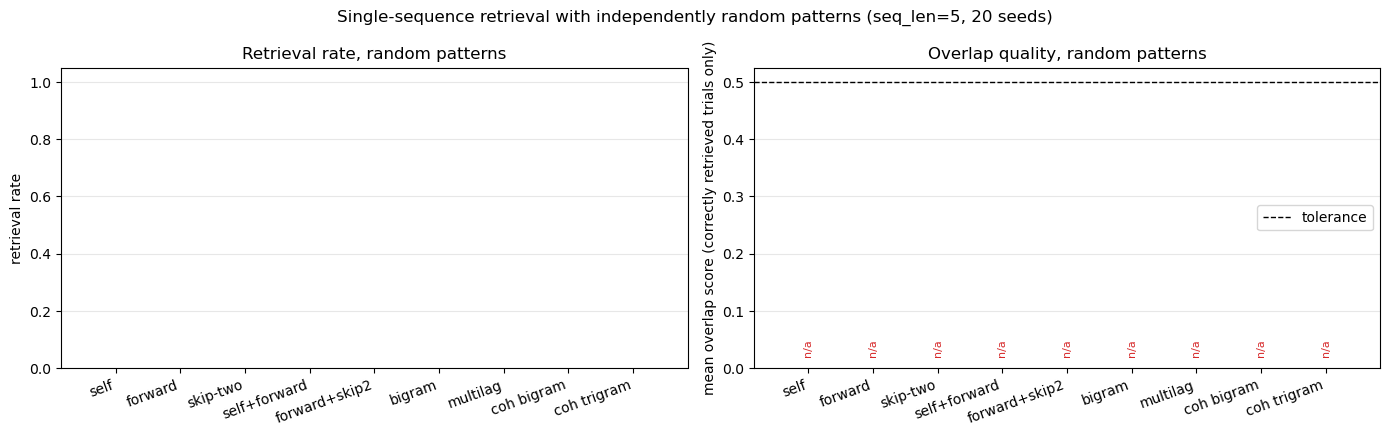

In [11]:
random_results = single_sequence_score_sweep(RAW_CATALOGUE, seq_len=5,
                                             corruption_rate=CONFIG["corruption_rate"],
                                             N=N, trials=20, random_patterns=True)

print(f"Random (uncorrelated) patterns, P=5, 20 seeds")
for name, r in random_results.items():
    overlap_str = f"{r['mean_overlap']:+.3f}" if r["mean_overlap"] == r["mean_overlap"] else "n/a (0% retrieval)"
    print(f"{name:<15} retrieval_rate={r['retrieval_rate']:>5.0%}   mean_overlap={overlap_str}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
names = list(random_results.keys())

axes[0].bar(names, [random_results[n]["retrieval_rate"] for n in names])
axes[0].set_ylabel("retrieval rate")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Retrieval rate, random patterns")

overlap_vals = [random_results[n]["mean_overlap"] for n in names]
bar_heights = [0.0 if v != v else v for v in overlap_vals]
bars = axes[1].bar(names, bar_heights)
for bar, v in zip(bars, overlap_vals):
    if v != v:
        axes[1].text(bar.get_x() + bar.get_width() / 2, 0.02, "n/a",
                     ha="center", va="bottom", fontsize=8, rotation=90, color="tab:red")
axes[1].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1, label="tolerance")
axes[1].set_ylabel("mean overlap score (correctly retrieved trials only)")
axes[1].set_title("Overlap quality, random patterns")
axes[1].legend()

for ax in axes:
    ax.set_xticks(range(len(names)), names, rotation=20, ha="right")
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Single-sequence retrieval with independently random patterns (seq_len=5, 20 seeds)")
plt.tight_layout(); plt.show()

### A few example trajectories

`retrieval_rate=0%` across the board is a strong claim -- worth seeing directly rather than
only as a number. Below: one random-pattern sequence each for a spread of rules (simplest
to most context-heavy), cued from `seq[0]`, plotting overlap with every stored pattern over
time.

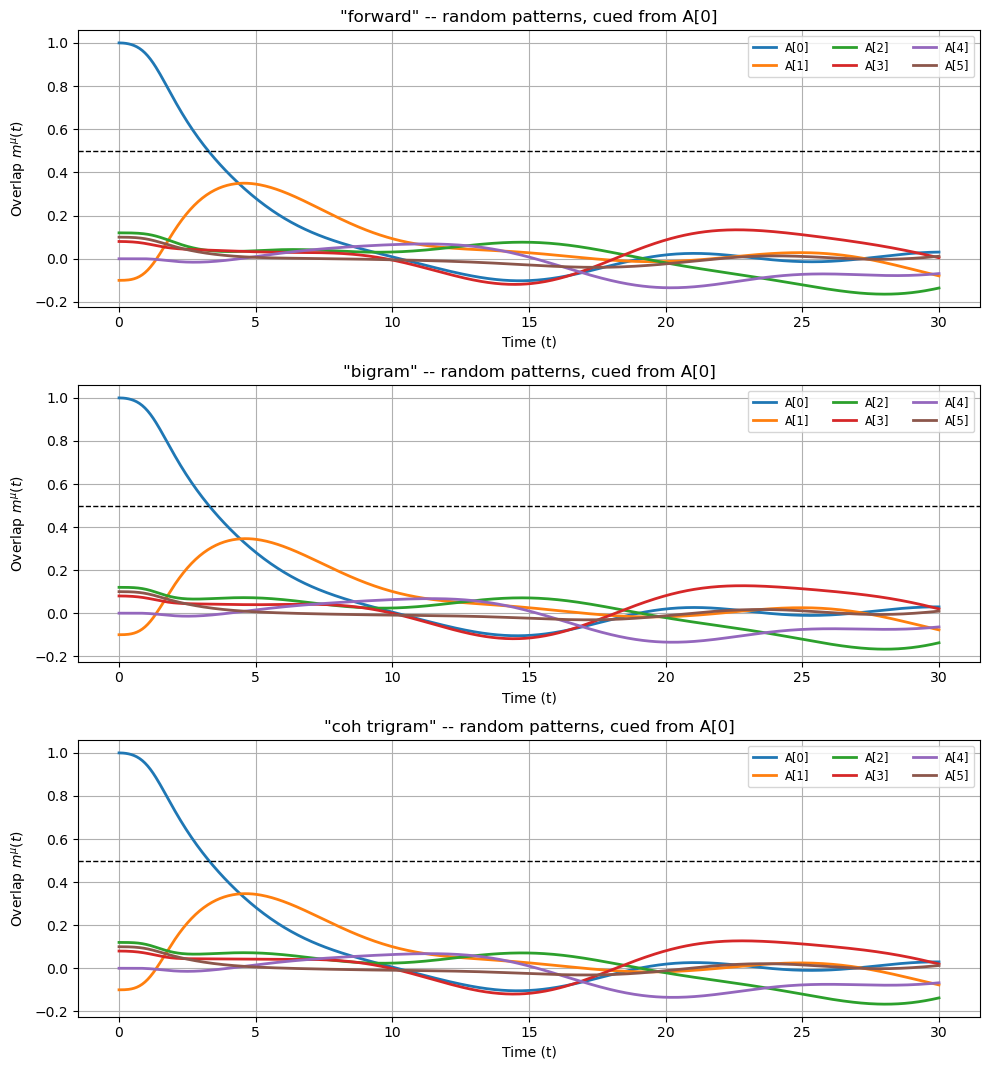

In [12]:
EXAMPLE_RULES = ["forward", "bigram", "coh trigram"]

fig, axes = plt.subplots(len(EXAMPLE_RULES), 1, figsize=(10, 3.6 * len(EXAMPLE_RULES)))
for ax, name in zip(axes, EXAMPLE_RULES):
    net = kc.ContextNetwork(rule=RAW_CATALOGUE[name], N=N, seed=10, **CONFIG)
    seq = generate_random_sequence(N, seq_len=5, name="A", seed=0)
    result = net.simulate(seq)
    net.plot(result, seq, ax=ax, title=f'"{name}" -- random patterns, cued from A[0]')
    ax.axhline(CONFIG["tolerance"], color="k", ls="--", lw=1)
plt.tight_layout(); plt.show()

## Findings

*(to be filled in from the executed results above)*